# Train Source Binary Ore Segmentation

This notebook trains the first ore/background segmentation model from binary masks generated from `masks_colored`. It follows the source ore-type training notebook pattern: 4x-downsampled images and masks, train-set standard scaling, GPU-resident cached tensors, GPU-side train-only augmentation, one epoch-level `tqdm`, periodic test-loss evaluation, serial-numbered checkpoints in `models/source_binary_segmentation/<MODEL_SERIAL>`, and history plots after training.

In [17]:
from pathlib import Path
from collections import Counter
import json
import sys

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / 'src').exists():
            PROJECT_ROOT = parent
            break
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from ore_detection.data.color_mask import convert_color_mask_file
from ore_detection.training.source_dataset import list_source_samples, load_sample_images
from ore_detection.training.source_binary_downsample import prepare_downsampled_source_binary_dataset
from ore_detection.training.source_binary_gpu_training import (
    augment_source_binary_batch,
    binary_dice_loss_from_logits,
    binary_iou_from_logits,
    iter_cached_binary_batches,
    list_downsampled_source_binary_samples,
    load_cached_binary_tensors,
    normalize_binary_images,
)
from ore_detection.training.source_binary_const import (
    SOURCE_BINARY_DOWNSAMPLE_FACTOR,
    SOURCE_BINARY_TRAIN_RGB_MEAN,
    SOURCE_BINARY_TRAIN_RGB_STD,
    SOURCE_BINARY_TRAIN_STATS_IMAGE_COUNT,
)
from ore_detection.visualization.overlay import save_overlay
from ore_detection.models.simple_unet import create_simple_unet

PROJECT_ROOT

WindowsPath('c:/Users/Cape/PycharmProjects/ore_detection')

In [32]:
DATASETS_ROOT = PROJECT_ROOT / 'datasets'
BINARY_MASKS_ROOT = PROJECT_ROOT / 'data_work' / 'binary_masks'
DOWNSAMPLED_ROOT = PROJECT_ROOT / 'data_work' / 'source_binary_downsampled'
QA_OVERLAYS_ROOT = PROJECT_ROOT / 'data_work' / 'qa_overlays' / 'binary'
PREDICTION_ROOT = PROJECT_ROOT / 'data_work' / 'predictions' / 'source_binary_segmentation'
MODEL_SERIAL = '001'
MODELS_ROOT = PROJECT_ROOT / 'models' / 'source_binary_segmentation' / MODEL_SERIAL

DATASETS = ('set_1', 'set_2', 'set_3')
RUN_MASK_CONVERSION = False
RUN_DOWNSAMPLE_PREP = False
RUN_QA_OVERLAYS = False
RUN_TRAINING = False
IMAGE_SIZE = 512
BATCH_SIZE = 2
EPOCHS = 200
LEARNING_RATE = 1e-4
EVAL_EVERY_N_EPOCHS = 1
DEVICE = 'cuda'
USE_GPU_CACHE = True
USE_GPU_AUGMENTATION = True
PIN_MEMORY = True
NUM_WORKERS = 0
AUG_SCALE_RANGE = (0.5, 2.0)
AUG_BRIGHTNESS_RANGE = (0.6, 1.4)
AUG_CONTRAST_RANGE = (0.6, 1.4)

print('project', PROJECT_ROOT)
print('python', sys.version)

project c:\Users\Cape\PycharmProjects\ore_detection
python 3.13.11 (tags/v3.13.11:6278944, Dec  5 2025, 16:26:58) [MSC v.1944 64 bit (AMD64)]


Generate source binary masks and downsampled train files before training:

```bash
py -3.13 scripts/convert_source_masks.py --dataset set_1
py -3.13 scripts/convert_source_masks.py --dataset set_2
py -3.13 scripts/convert_source_masks.py --dataset set_3
py -3.13 scripts/prepare_source_binary_downsampled_dataset.py
```

Set `RUN_MASK_CONVERSION = True` or `RUN_DOWNSAMPLE_PREP = True` only when you want this notebook to regenerate those artifacts.

In [19]:
def convert_dataset_color_masks(dataset: str) -> dict:
    source_root = DATASETS_ROOT / dataset / 'masks_colored'
    target_root = BINARY_MASKS_ROOT / dataset
    converted = ore_pixels = total_pixels = 0
    for source_path in sorted(source_root.rglob('*.png')):
        rel = source_path.relative_to(source_root)
        stats = convert_color_mask_file(source_path, target_root / rel)
        converted += 1
        ore_pixels += stats['ore_pixels']
        total_pixels += stats['total_pixels']
    return {
        'dataset': dataset,
        'converted': converted,
        'ore_fraction': ore_pixels / total_pixels if total_pixels else 0.0,
    }

if RUN_MASK_CONVERSION:
    conversion_reports = [convert_dataset_color_masks(dataset) for dataset in DATASETS]
else:
    conversion_reports = [{'skipped': True, 'reason': 'RUN_MASK_CONVERSION is False'}]
conversion_reports

[{'skipped': True, 'reason': 'RUN_MASK_CONVERSION is False'}]

In [20]:
source_train_samples = list_source_samples(
    datasets_root=DATASETS_ROOT,
    binary_masks_root=BINARY_MASKS_ROOT,
    datasets=DATASETS,
    split='train',
)
source_test_samples = list_source_samples(
    datasets_root=DATASETS_ROOT,
    binary_masks_root=BINARY_MASKS_ROOT,
    datasets=DATASETS,
    split='test',
)
all_source_samples = source_train_samples + source_test_samples
counts = Counter((sample.dataset, sample.split) for sample in all_source_samples)
print(f'original train samples: {len(source_train_samples)}')
print(f'original test samples: {len(source_test_samples)}')
print(counts)
assert all_source_samples, 'No binary masks found. Run scripts/convert_source_masks.py for set_1, set_2, and set_3.'

if RUN_DOWNSAMPLE_PREP:
    prep_summary = prepare_downsampled_source_binary_dataset(
        datasets_root=DATASETS_ROOT,
        binary_masks_root=BINARY_MASKS_ROOT,
        output_root=DOWNSAMPLED_ROOT,
        const_path=PROJECT_ROOT / 'src' / 'ore_detection' / 'training' / 'source_binary_const.py',
        factor=SOURCE_BINARY_DOWNSAMPLE_FACTOR,
    )
    print(json.dumps(prep_summary, indent=2))
else:
    print('RUN_DOWNSAMPLE_PREP is False; using existing downsampled files.')

original train samples: 134
original test samples: 46
Counter({('set_1', 'train'): 64, ('set_2', 'train'): 37, ('set_3', 'train'): 33, ('set_1', 'test'): 20, ('set_3', 'test'): 14, ('set_2', 'test'): 12})
RUN_DOWNSAMPLE_PREP is False; using existing downsampled files.


In [21]:
def write_qa_overlays(samples, limit_per_dataset=3):
    written = 0
    per_dataset = Counter()
    for sample in samples:
        if per_dataset[sample.dataset] >= limit_per_dataset:
            continue
        image, mask = load_sample_images(sample)
        output_path = QA_OVERLAYS_ROOT / sample.dataset / sample.split / f'{sample.stem}_overlay.png'
        save_overlay(image, mask, output_path, alpha=96)
        per_dataset[sample.dataset] += 1
        written += 1
    return written, per_dataset

if RUN_QA_OVERLAYS:
    written, per_dataset = write_qa_overlays(source_test_samples, limit_per_dataset=3)
else:
    written, per_dataset = 0, Counter()
print('qa_written', written, per_dataset, 'root', QA_OVERLAYS_ROOT)

qa_written 0 Counter() root c:\Users\Cape\PycharmProjects\ore_detection\data_work\qa_overlays\binary


In [22]:
train_samples = list_downsampled_source_binary_samples(DOWNSAMPLED_ROOT, split='train')
test_samples = list_downsampled_source_binary_samples(DOWNSAMPLED_ROOT, split='test')
print(f'downsampled train samples: {len(train_samples)}')
print(f'downsampled test samples: {len(test_samples)}')
print(f'train RGB mean: {SOURCE_BINARY_TRAIN_RGB_MEAN}')
print(f'train RGB std: {SOURCE_BINARY_TRAIN_RGB_STD}')
print(f'train stats image count: {SOURCE_BINARY_TRAIN_STATS_IMAGE_COUNT}')
if train_samples:
    train_samples[0]

downsampled train samples: 134
downsampled test samples: 46
train RGB mean: (0.4691853836690349, 0.4398698336579204, 0.4024980066350099)
train RGB std: (0.25512571009385043, 0.2335228905839328, 0.2100037541533096)
train stats image count: 134


In [23]:
try:
    import torch
except ModuleNotFoundError:
    torch = None
    print('PyTorch is not installed. Install the ml optional dependencies to train.')

if torch is not None and train_samples:
    preview_cache = load_cached_binary_tensors(train_samples[: min(2, len(train_samples))], device=torch.device('cpu'))
    print('preview image', tuple(preview_cache['image'].shape), preview_cache['image'].dtype)
    print('preview mask', tuple(preview_cache['mask'].shape), preview_cache['mask'].dtype)
elif not train_samples:
    print('No downsampled files found. Run scripts/prepare_source_binary_downsampled_dataset.py first.')

preview image (2, 3, 636, 848) torch.float32
preview mask (2, 636, 848) torch.uint8


In [24]:
def compute_segmentation_loss(model, image, target, criterion):
    logits = model(image)
    bce_loss = criterion(logits, target)
    dice_loss = binary_dice_loss_from_logits(logits, target)
    loss = bce_loss + dice_loss
    iou = binary_iou_from_logits(logits.detach(), target)
    return loss, {
        'loss': float(loss.detach().cpu()),
        'bce_loss': float(bce_loss.detach().cpu()),
        'dice_loss': float(dice_loss.detach().cpu()),
        'iou': float(iou.detach().cpu()),
    }


def mean_metrics(rows):
    if not rows:
        return {'loss': None, 'bce_loss': None, 'dice_loss': None, 'iou': None}
    return {key: sum(row[key] for row in rows) / len(rows) for key in rows[0]}

In [25]:
def train_one_epoch(model, cached, optimizer, criterion, device):
    model.train()
    rows = []
    for batch in iter_cached_binary_batches(cached, batch_size=BATCH_SIZE, shuffle=True):
        image = batch['image'].to(device, non_blocking=True)
        mask = batch['mask'].to(device, non_blocking=True)
        if USE_GPU_AUGMENTATION:
            image, mask = augment_source_binary_batch(
                image,
                mask,
                output_size=IMAGE_SIZE,
                scale_range=AUG_SCALE_RANGE,
                brightness_range=AUG_BRIGHTNESS_RANGE,
                contrast_range=AUG_CONTRAST_RANGE,
            )
        image = normalize_binary_images(image, mean=SOURCE_BINARY_TRAIN_RGB_MEAN, std=SOURCE_BINARY_TRAIN_RGB_STD)

        optimizer.zero_grad(set_to_none=True)
        loss, metrics = compute_segmentation_loss(model, image, mask, criterion)
        loss.backward()
        optimizer.step()
        rows.append(metrics)
    return mean_metrics(rows)


@torch.no_grad()
def evaluate(model, cached, criterion, device):
    model.eval()
    rows = []
    for batch in iter_cached_binary_batches(cached, batch_size=BATCH_SIZE, shuffle=False):
        image = batch['image'].to(device, non_blocking=True)
        mask = batch['mask'].to(device, non_blocking=True)
        image = normalize_binary_images(image, mean=SOURCE_BINARY_TRAIN_RGB_MEAN, std=SOURCE_BINARY_TRAIN_RGB_STD)
        _, metrics = compute_segmentation_loss(model, image, mask, criterion)
        rows.append(metrics)
    return mean_metrics(rows)

In [26]:
def checkpoint_payload(model, optimizer, *, epoch, train_metrics, test_metrics, best_test_loss):
    return {
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'epoch': epoch,
        'train_metrics': train_metrics,
        'test_metrics': test_metrics,
        'best_test_loss': best_test_loss,
        'image_size': IMAGE_SIZE,
        'learning_rate': LEARNING_RATE,
        'normalization': {
            'mean': SOURCE_BINARY_TRAIN_RGB_MEAN,
            'std': SOURCE_BINARY_TRAIN_RGB_STD,
            'train_stats_image_count': SOURCE_BINARY_TRAIN_STATS_IMAGE_COUNT,
        },
        'augmentation': {
            'use_gpu_augmentation': USE_GPU_AUGMENTATION,
            'scale_range': AUG_SCALE_RANGE,
            'brightness_range': AUG_BRIGHTNESS_RANGE,
            'contrast_range': AUG_CONTRAST_RANGE,
        },
        'notebook': '01_train_source_binary_segmentation.ipynb',
    }

In [27]:
def plot_training_history(history):
    metric_specs = [
        ('loss', 'total loss'),
        ('bce_loss', 'binary cross entropy loss'),
        ('dice_loss', 'dice loss'),
        ('iou', 'binary ore IoU'),
    ]
    epochs = [row['epoch'] for row in history]
    fig, axes = plt.subplots(len(metric_specs), 1, figsize=(10, 12), sharex=True, constrained_layout=True)
    for axis, (metric_name, title) in zip(axes, metric_specs):
        train_values = [row['train'][metric_name] for row in history]
        test_values = [row['test'][metric_name] if row['test'] is not None else None for row in history]
        axis.plot(epochs, train_values, marker='o', label='train')
        axis.plot(epochs, test_values, marker='o', label='test')
        axis.set_title(title)
        axis.set_ylabel(metric_name)
        axis.grid(True, alpha=0.3)
        axis.legend()
    axes[-1].set_xlabel('epoch')
    plt.show()
    return fig

In [34]:
RUN_TRAINING = False

Training:   0%|          | 0/200 [00:00<?, ?it/s]

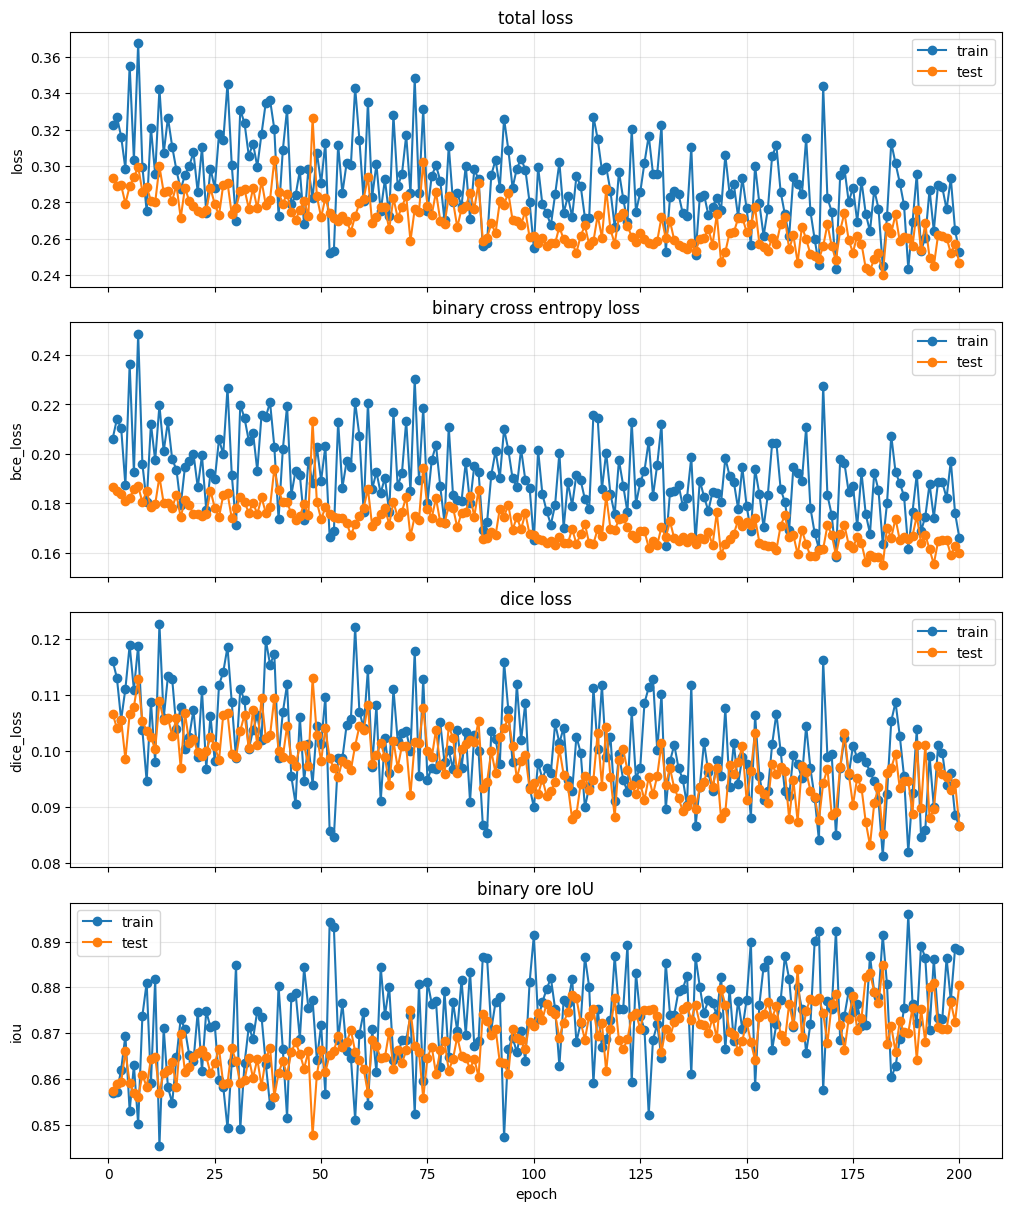

In [35]:
if RUN_TRAINING:
    if torch is None:
        raise RuntimeError('PyTorch is required for training.')
    if not train_samples:
        raise RuntimeError('No downsampled train files found. Run scripts/prepare_source_binary_downsampled_dataset.py first.')
    if not test_samples:
        raise RuntimeError('No downsampled test files found. Run scripts/prepare_source_binary_downsampled_dataset.py first.')
    if SOURCE_BINARY_TRAIN_STATS_IMAGE_COUNT == 0:
        raise RuntimeError('Train RGB stats are empty. Run scripts/prepare_source_binary_downsampled_dataset.py first.')

    device = torch.device(DEVICE if DEVICE == 'cuda' and torch.cuda.is_available() else 'cpu')
    if device.type == 'cuda':
        torch.backends.cudnn.benchmark = True
    cache_device = device if USE_GPU_CACHE and device.type == 'cuda' else torch.device('cpu')
    use_pin_memory = PIN_MEMORY and cache_device.type == 'cpu' and device.type == 'cuda'

    MODELS_ROOT.mkdir(parents=True, exist_ok=True)
    train_cache = load_cached_binary_tensors(train_samples, device=cache_device, pin_memory=use_pin_memory)
    test_cache = load_cached_binary_tensors(test_samples, device=cache_device, pin_memory=use_pin_memory)

    # model = create_simple_unet(out_channels=1, base_channels=16).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    criterion = torch.nn.BCEWithLogitsLoss()

    history = []
    best_test_loss = float('inf')
    with tqdm(range(1, EPOCHS + 1), desc='Training') as pbar:
        for epoch in pbar:
            train_metrics = train_one_epoch(model, train_cache, optimizer, criterion, device)
            test_metrics = None
            if epoch % EVAL_EVERY_N_EPOCHS == 0 or epoch == EPOCHS:
                test_metrics = evaluate(model, test_cache, criterion, device)

            row = {'epoch': epoch, 'train': train_metrics, 'test': test_metrics}
            history.append(row)
            postfix = {
                'train_loss': f"{train_metrics['loss']:.4f}",
                'train_iou': f"{train_metrics['iou']:.4f}",
            }
            if test_metrics is not None:
                postfix['test_loss'] = f"{test_metrics['loss']:.4f}"
                postfix['test_iou'] = f"{test_metrics['iou']:.4f}"
            pbar.set_postfix(postfix)

            torch.save(
                checkpoint_payload(
                    model,
                    optimizer,
                    epoch=epoch,
                    train_metrics=train_metrics,
                    test_metrics=test_metrics,
                    best_test_loss=best_test_loss,
                ),
                MODELS_ROOT / 'last.pt',
            )
            if test_metrics is not None and test_metrics['loss'] < best_test_loss:
                best_test_loss = test_metrics['loss']
                torch.save(
                    checkpoint_payload(
                        model,
                        optimizer,
                        epoch=epoch,
                        train_metrics=train_metrics,
                        test_metrics=test_metrics,
                        best_test_loss=best_test_loss,
                    ),
                    MODELS_ROOT / 'best.pt',
                )
            (MODELS_ROOT / 'history.json').write_text(json.dumps(history, indent=2), encoding='utf-8')
    plot_training_history(history)
else:
    print('RUN_TRAINING is False; set it to True after downsample preparation and environment checks.')

In [ ]:
from PIL import Image

@torch.no_grad()
def save_prediction_for_sample(model, sample, output_root=PREDICTION_ROOT, threshold=0.5):
    image, _ = load_sample_images(sample)
    resized = image.resize((IMAGE_SIZE, IMAGE_SIZE), Image.Resampling.BILINEAR)
    data = list(resized.convert('RGB').tobytes())
    tensor = torch.tensor(data, dtype=torch.float32).view(IMAGE_SIZE, IMAGE_SIZE, 3).permute(2, 0, 1).unsqueeze(0) / 255.0
    tensor = normalize_binary_images(tensor, mean=SOURCE_BINARY_TRAIN_RGB_MEAN, std=SOURCE_BINARY_TRAIN_RGB_STD)
    logits = model(tensor.to(device))
    prob = torch.sigmoid(logits)[0, 0].detach().cpu()
    prob_image = Image.fromarray((prob.numpy() * 255).astype('uint8')).resize(image.size, Image.Resampling.BILINEAR)
    mask_image = prob_image.point(lambda value: 1 if value >= int(threshold * 255) else 0, mode='L')
    sample_dir = Path(output_root) / sample.dataset / sample.split / sample.stem
    sample_dir.mkdir(parents=True, exist_ok=True)
    mask_image.save(sample_dir / 'ore_mask.png')
    prob_image.save(sample_dir / 'ore_confidence.png')
    save_overlay(image, mask_image, sample_dir / 'overlay.png')
    (sample_dir / 'metadata.json').write_text(json.dumps({
        'image_path': str(sample.image_path),
        'source_mask_path': str(sample.mask_path),
        'threshold': threshold,
        'image_size': IMAGE_SIZE,
    }, indent=2), encoding='utf-8')
    return sample_dir